# Displacement Then Qubit Spectroscopy


This notebook rewrites `examples/displacement_qubit_spectroscopy.py` as a guided number-splitting tutorial. We first displace the storage cavity into a coherent state, then sweep a weak qubit probe tone and read out the final excited-state population.

The physical signature is photon-number-dependent qubit spectroscopy: with dispersive `chi < 0`, each extra cavity photon shifts the qubit transition to lower transition detuning in the matched rotating frame. The resulting peak heights track the displaced cavity's Fock-state weights.


## Imports


In [1]:
from __future__ import annotations

from pathlib import Path
import sys

REPO_ROOT = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "pyproject.toml").exists() and (candidate / "cqed_sim").is_dir()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Could not resolve the repository root from the notebook working directory.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import qutip as qt

from tutorials.workflow_tutorial_support import configure_notebook_style

configure_notebook_style()

from cqed_sim import (
    DisplacementGate,
    DispersiveTransmonCavityModel,
    FrameSpec,
    Pulse,
    SequenceCompiler,
    SimulationConfig,
    build_displacement_pulse,
    carrier_for_transition_frequency,
    simulate_sequence,
)
from cqed_sim.pulses import square_envelope
from tutorials.tutorial_support import GHz, MHz, angular_to_mhz, ns, us


## Physics / model definition


In [2]:
model = DispersiveTransmonCavityModel(
    omega_c=GHz(5.0),
    omega_q=GHz(6.0),
    alpha=MHz(-220.0),
    chi=MHz(-2.84),
    kerr=MHz(-0.002),
    n_cav=18,
    n_tr=2,
)
frame = FrameSpec(omega_c_frame=model.omega_c, omega_q_frame=model.omega_q)

displacement_gate = DisplacementGate(index=0, name="displace_alpha_1p25", re=1.25, im=0.0)
probe_duration_s = 1.2 * us
probe_gap_s = 20.0 * ns
probe_amp_rad_s = 2.0 * np.pi * 0.18e6
transition_scan_mhz = np.linspace(-12.0, 2.0, 41)


## Pulse / sequence construction


In [3]:
displacement_pulses, displacement_drive_ops, displacement_meta = build_displacement_pulse(
    displacement_gate,
    {"duration_displacement_s": 120.0 * ns},
)
displacement_duration_s = float(displacement_meta["duration_s"])
dt_s = 0.5 * ns

displacement_compiled = SequenceCompiler(dt=dt_s).compile(
    displacement_pulses,
    t_end=displacement_duration_s + dt_s,
)

def final_excited_population_for_detuning(detuning_mhz: float) -> float:
    probe = Pulse(
        "qubit",
        t0=displacement_duration_s + probe_gap_s,
        duration=probe_duration_s,
        envelope=square_envelope,
        amp=probe_amp_rad_s,
        carrier=carrier_for_transition_frequency(MHz(detuning_mhz)),
        label=f"probe_{detuning_mhz:+.2f}_MHz",
    )
    compiled = SequenceCompiler(dt=dt_s).compile(
        displacement_pulses + [probe],
        t_end=displacement_duration_s + probe_gap_s + probe_duration_s + dt_s,
    )
    result = simulate_sequence(
        model,
        compiled,
        model.basis_state(0, 0),
        {**displacement_drive_ops, "qubit": "qubit"},
        config=SimulationConfig(frame=frame),
    )
    return float(np.real(result.expectations["P_e"][-1]))

print("Displacement metadata:", displacement_meta)


Displacement metadata: {'mapping': 'Square cavity drive with analytic rotating-frame calibration alpha = -i * integral epsilon(t) dt.', 'duration_s': 1.2000000000000002e-07, 'drive_amp': 10416666.666666666, 'drive_phase': 1.5707963267948966, 'target_alpha': (1.25+0j)}


## Simulation


In [4]:
displacement_only = simulate_sequence(
    model,
    displacement_compiled,
    model.basis_state(0, 0),
    displacement_drive_ops,
    config=SimulationConfig(frame=frame),
)

rho_after_displacement = displacement_only.final_state
rho_storage = qt.ptrace(rho_after_displacement, 1)
if not rho_storage.isoper:
    rho_storage = rho_storage.proj()

photon_weights = np.clip(np.real(np.diag(rho_storage.full())), 0.0, 1.0)
photon_weights = photon_weights / max(np.sum(photon_weights), 1.0e-12)
nbar = float(np.real((rho_storage * qt.num(model.n_cav)).tr()))

spectroscopy_response = np.asarray(
    [final_excited_population_for_detuning(point_mhz) for point_mhz in transition_scan_mhz],
    dtype=float,
)
fock_levels = np.arange(min(6, model.n_cav), dtype=int)
predicted_lines_mhz = np.asarray(
    [angular_to_mhz(model.manifold_transition_frequency(int(n), frame=frame)) for n in fock_levels],
    dtype=float,
)

print("Post-displacement <n>:", nbar)
print("Predicted n-resolved qubit lines [MHz]:", predicted_lines_mhz)


Post-displacement <n>: 1.554417932837371
Predicted n-resolved qubit lines [MHz]: [  0.    -2.84  -5.68  -8.52 -11.36 -14.2 ]


## Analysis / visualization


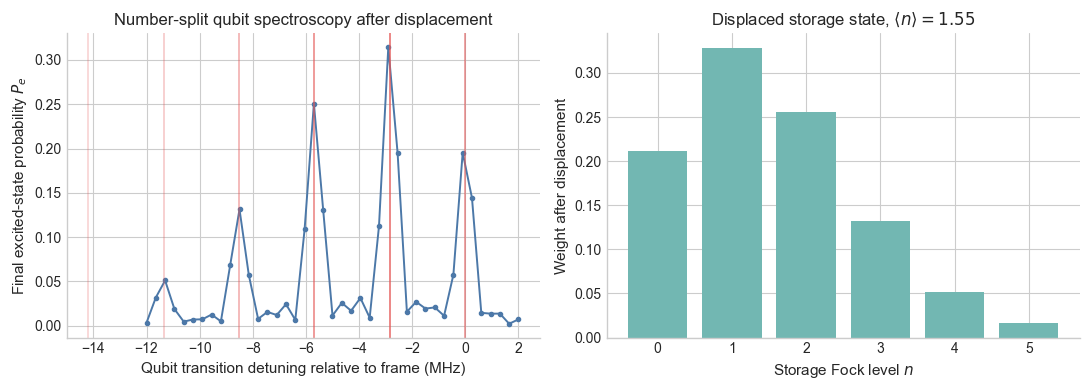

In [5]:
fig, (ax_spec, ax_weights) = plt.subplots(1, 2, figsize=(11.0, 4.0))

ax_spec.plot(transition_scan_mhz, spectroscopy_response, "o-", ms=3.0, lw=1.4, color="#4C78A8")
for line_mhz, weight in zip(predicted_lines_mhz, photon_weights[: predicted_lines_mhz.size], strict=True):
    ax_spec.axvline(
        line_mhz,
        color="#E45756",
        alpha=min(0.95, 0.25 + 2.0 * float(weight)),
        lw=1.1,
    )
ax_spec.set_xlabel("Qubit transition detuning relative to frame (MHz)")
ax_spec.set_ylabel("Final excited-state probability $P_e$")
ax_spec.set_title("Number-split qubit spectroscopy after displacement")

ax_weights.bar(fock_levels, photon_weights[: fock_levels.size], color="#72B7B2")
ax_weights.set_xlabel("Storage Fock level $n$")
ax_weights.set_ylabel("Weight after displacement")
ax_weights.set_title(rf"Displaced storage state, $\langle n \rangle = {nbar:.2f}$")

plt.tight_layout()
plt.show()


## Interpretation


The cavity displacement prepares a coherent-state-like Fock distribution, so the spectroscopy curve is not a single Lorentzian. Instead, each photon number manifold contributes its own line, separated by `chi`.

Because this repository defines `chi` as the per-photon qubit-transition pull, negative `chi` moves the `n`-resolved qubit lines to lower transition detuning. The notebook uses `carrier_for_transition_frequency(...)` so the carrier sign follows the repository convention automatically.


## Variations / exercises


- Increase the displacement amplitude to make higher-`n` peaks visible.
- Reduce the probe amplitude and lengthen the probe duration if you want sharper but slower spectroscopy.
- Compare the measured line heights with a Poisson model for the displaced cavity.
